<a href="https://colab.research.google.com/github/laibatabassum456/Data_Analysis/blob/main/INSURANCE_CLAIM_PREDICTION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATA

In [2]:
df = pd.read_csv('/content/insurance.csv')

UNDERSTAND DATA

In [6]:
df.head()
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


CHECK MISSING VALUES

In [7]:
df.isnull().sum()
df.fillna(method='ffill', inplace=True)

/tmp/ipykernel_36955/2903114193.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


VISUALIZATION

Age vs Charges

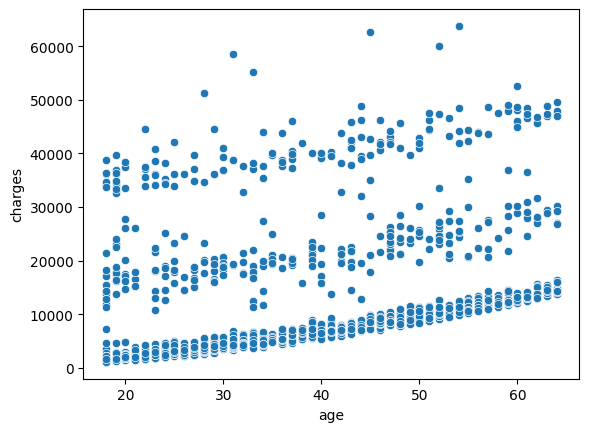

In [8]:
sns.scatterplot(x='age', y='charges', data=df)
plt.show()

BMI vs Charges

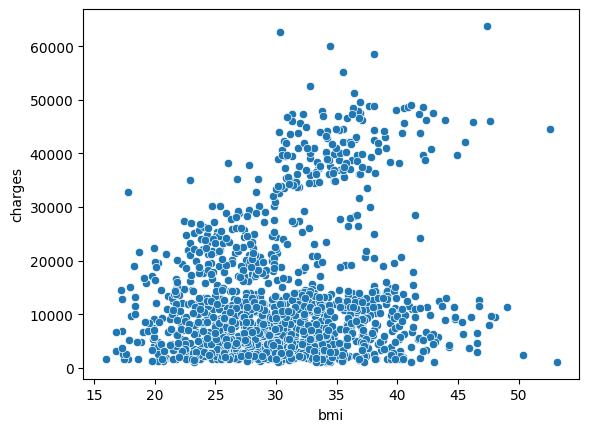

In [9]:
sns.scatterplot(x='bmi', y='charges', data=df)
plt.show()

Smoker Impact

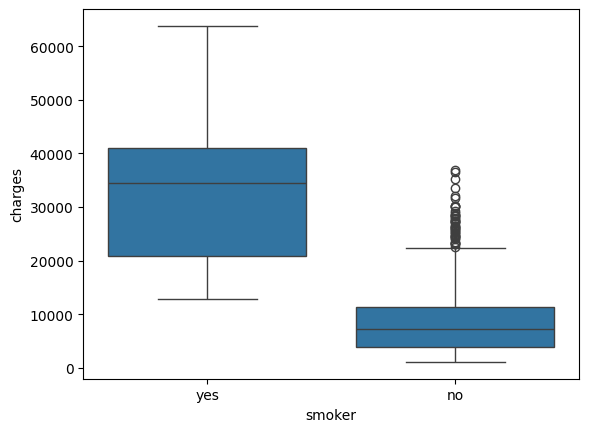

In [10]:
sns.boxplot(x='smoker', y='charges', data=df)
plt.show()

ENCODE CATEGORICAL DATA

In [11]:
df = pd.get_dummies(df, drop_first=True)

DEFINE INPUT & OUTPUT

In [12]:
X = df.drop('charges', axis=1)
y = df['charges']

TRAIN-TEST SPLIT

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

TRAIN MODEL

In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

PREDICTION

In [15]:
y_pred = model.predict(X_test)

EVALUATION

In [16]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

MAE: 4708.610459034039
RMSE: 6930.160981063407


This project predicts medical insurance charges using Linear Regression.
The analysis showed that age, BMI, and smoking status significantly impact insurance costs.
The model performed well based on MAE and RMSE evaluation metrics.